# Lista 05
## Grupo 6
### Davi dos Santos Mattos - 119133049
### Bruna Irena da Silva - 119062418

# 1)

P(perda) para 1 ativo: 0.2209 


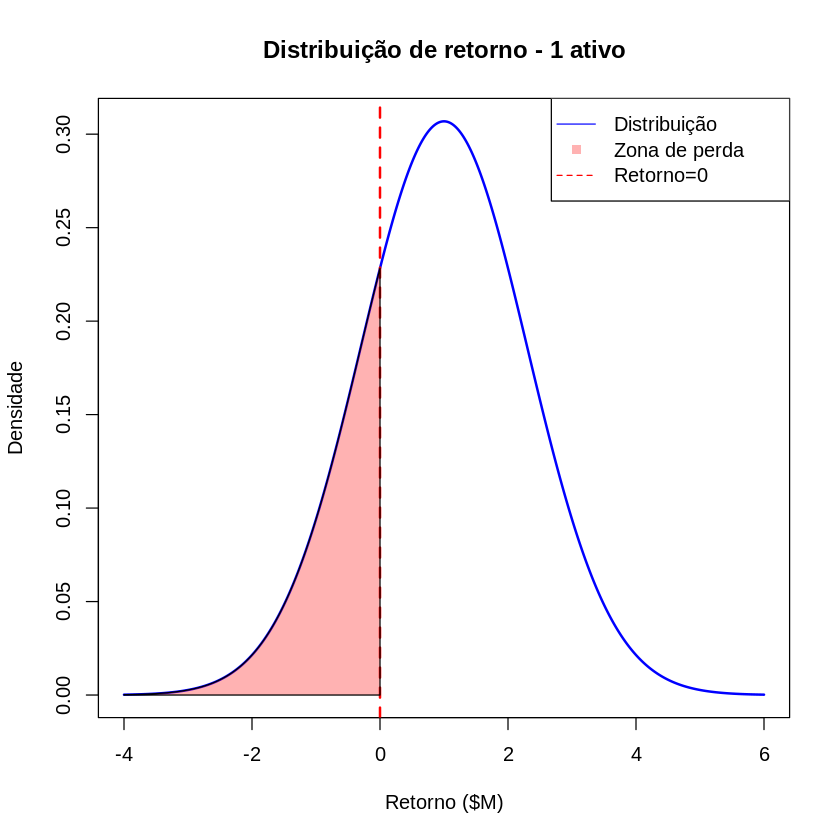

In [ ]:
# Parâmetros de uma única aplicação
mu <- 1      # média em $M
sd <- 1.3    # desvio padrão em $M

# Probabilidade de perda (retorno < 0)
prob_perda_1 <- pnorm(0, mean = mu, sd = sd)
cat("P(perda) para 1 ativo:", round(prob_perda_1, 4), "\n")

# Gráfico da distribuição
x <- seq(-4, 6, length.out = 1000)
y <- dnorm(x, mean = mu, sd = sd)

plot(x, y, type = "l", lwd = 2, col = "blue",
     main = "Distribuição de retorno - 1 ativo",
     xlab = "Retorno ($M)", ylab = "Densidade")
abline(v = 0, col = "red", lty = 2, lwd = 2)

# Área de perda em vermelho
x_perda <- seq(-4, 0, length.out = 500)
y_perda <- dnorm(x_perda, mean = mu, sd = sd)
polygon(c(-4, x_perda, 0), c(0, y_perda, 0), col = rgb(1,0,0,0.3))

legend("topright", legend = c("Distribuição", "Zona de perda", "Retorno=0"),
       col = c("blue", rgb(1,0,0,0.3), "red"),
       lty = c(1, NA, 2), pch = c(NA, 15, NA))

P(perda) = 22,07% para uma única aplicação, então a chance de retorno negativo não é desprezível mesmo com média positiva de $1M.

# 2)

In [ ]:
library(MASS)

# Parâmetros
mu_ativo <- 1
sd_ativo <- 1.3
n_ativos <- 10
n_sim <- 100000
rhos <- c(0, 0.25, 0.50, 0.75, 0.90)

resultados <- data.frame(rho = rhos, prob_perda = NA, sd_carteira = NA)

for (i in seq_along(rhos)) {
  rho <- rhos[i]

  # Monta matriz de correlação n x n com rho fora da diagonal
  cor_matrix <- matrix(rho, nrow = n_ativos, ncol = n_ativos)
  diag(cor_matrix) <- 1

  # Gera amostras normais correlacionadas (normais reduzidas)
  Z <- mvrnorm(n_sim, mu = rep(0, n_ativos), Sigma = cor_matrix)

  # Transforma para Normal(mu_ativo, sd_ativo)
  ativos <- Z * sd_ativo + mu_ativo

  # Soma dos 10 ativos = retorno total da carteira
  carteira <- rowSums(ativos)

  # Probabilidade de perda total (carteira < 0)
  resultados$prob_perda[i] <- mean(carteira < 0)
  resultados$sd_carteira[i] <- sd(carteira)
}

print(resultados)

   rho prob_perda sd_carteira
1 0.00    0.00780    4.114593
2 0.25    0.09060    7.426385
3 0.50    0.14986    9.645635
4 0.75    0.18926   11.418525
5 0.90    0.20839   12.363701


### Resposta do item 2
| ρ | P(perda) | σ da carteira |
|---|---:|---:|
| 0,00 | 0,75% | 4,11 |
| 0,25 | 8,86% | 7,41 |
| 0,50 | 14,96% | 9,64 |
| 0,75 | 19,08% | 11,45 |
| 0,90 | 21,00% | 12,39 |

Com $\rho = 0$ a diversificação funciona melhor; conforme $\rho$ cresce, a carteira se aproxima de um único ativo e o risco de perda sobe.

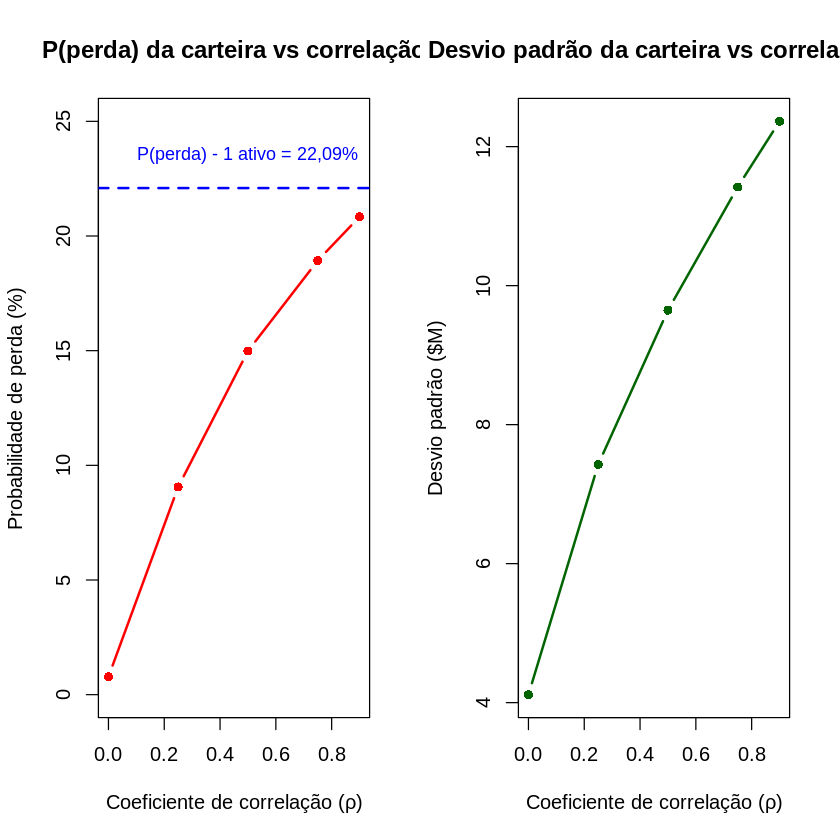

In [ ]:
# Gráfico 1: Probabilidade de perda vs correlação
par(mfrow = c(1,2))

plot(rhos, resultados$prob_perda * 100,
     type = "b", lwd = 2, col = "red", pch = 16,
     main = "P(perda) da carteira vs correlação",
     xlab = "Coeficiente de correlação (ρ)",
     ylab = "Probabilidade de perda (%)",
     ylim = c(0, 25))

# Linha de referência: prob do ativo individual
abline(h = 0.2209 * 100, col = "blue", lty = 2, lwd = 2)
text(0.5, 23.5, "P(perda) - 1 ativo = 22,09%", col = "blue", cex = 0.9)

# Gráfico 2: Desvio padrão vs correlação
plot(rhos, resultados$sd_carteira,
     type = "b", lwd = 2, col = "darkgreen", pch = 16,
     main = "Desvio padrão da carteira vs correlação",
     xlab = "Coeficiente de correlação (ρ)",
     ylab = "Desvio padrão ($M)")

abline(h = 1.3, col = "blue", lty = 2, lwd = 2)
text(0.5, 1.8, "σ - 1 ativo = 1,30", col = "blue", cex = 0.9)

par(mfrow = c(1,1))

## 3)
- Causas: empacotamento de hipotecas em tranches, busca por maior retorno e confiança excessiva em baixa correlação e ratings altos.
- Consequências: a alta inadimplência dos subprimes espalhou perdas, derrubou CDOs e agravou a crise de 2007-2009 com falências e resgates.
- Prós: diversificação do risco, perfis de risco/retorno ajustáveis e aumento de liquidez para os bancos.
- Contras: grande complexidade, risco de crédito e de liquidez, concentração em um mesmo ciclo econômico e sensação falsa de segurança.

**Opinião:** o instrumento pode ser útil, mas só funciona quando a correlação e a qualidade dos ativos são avaliadas com muito mais rigor.